<a href="https://colab.research.google.com/github/Muhammad-Ahmad-1263/urdu-ocr-codesaviours-si26-Muhammad-Ahmad/blob/main/SI26_Week4_Muhammad_Ahmad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Muhammad-Ahmad-1263/urdu-ocr-codesaviours-si26-Muhammad-Ahmad/blob/main/SI26_Week4_Muhammad_Ahmad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — Fine-Tune TrOCR on Urdu Dataset
### Code Saviours SI-26 · ML/AI Internship · Muhammad Ahmad

---

![Status](https://img.shields.io/badge/status-in--progress-yellow) ![Model](https://img.shields.io/badge/model-TrOCR--base--printed-blue) ![Language](https://img.shields.io/badge/language-Urdu-green) ![Framework](https://img.shields.io/badge/framework-PyTorch%20%7C%20Transformers-orange)

This notebook fine-tunes Microsoft's **TrOCR** (Transformer OCR) model to read printed **Urdu** text, using a custom dataset of signboards, newspaper clippings, and synthetic samples.

### Notebook Map

| # | Section | What it does |
|---|---|---|
| 1 | Environment Check | Confirms GPU is available |
| 2 | Upload & Extract Dataset | Loads your dataset zip |
| 3 | Install Dependencies | Installs required libraries |
| 4 | Dataset Class | Defines how images + labels are paired |
| 4.5 | Generate Synthetic Data | Creates extra training images instantly |
| 5 | Prepare Data | Filters to labeled rows, splits train/test |
| 6 | Load Pretrained Model | Loads TrOCR onto GPU |
| 6.5 | Extend Vocabulary for Urdu | Critical fix so the model can output Urdu characters |
| 7 | Configure Training | Sets up DataLoaders + optimiser |
| 8 | Train the Model | Fine-tunes on your Urdu data |
| 9 | Evaluate | Measures accuracy on unseen images |
| 10 | Save to Google Drive | Stores the fine-tuned model |
| 11 | Export Updated Dataset | Packages everything for GitHub |

**Before running anything:** `Runtime > Change runtime type > GPU`

**Run every cell in order, one at a time.** Sections 2 and 11 pause for manual file upload/download, so avoid "Run All" on a first pass.

---
## 1 - Environment Check

Confirms whether a GPU is attached to this Colab session. Training on CPU works but takes hours instead of minutes.

In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device available: {device}')

if device == 'cpu':
    print('WARNING: No GPU detected.')
    print('Go to Runtime > Change runtime type > GPU, then Restart session.')
else:
    print('GPU detected - ready to proceed.')

Device available: cuda
GPU detected - ready to proceed.


---
## 2 - Upload & Extract Dataset

Upload `week3_combined_dataset.zip` - the file your Week 3 notebook downloaded. This cell will:
- Show a "Choose Files" button (wait for it to appear)
- Extract the zip into a `data/` folder
- Verify `data/labels.csv` exists before letting you continue

**Do not skip this cell.** Every cell after it depends on `data/` existing.

In [2]:
import os

if os.path.exists('data/labels.csv'):
    print('data/labels.csv already exists in this session - skipping upload.')
    print('Contents of data/:', os.listdir('data'))
else:
    from google.colab import files
    import zipfile

    print('Please choose "week3_combined_dataset.zip" from your computer:')
    uploaded = files.upload()

    if len(uploaded) == 0:
        raise RuntimeError('No file was uploaded. Re-run this cell and select week3_combined_dataset.zip.')

    zip_name = list(uploaded.keys())[0]
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall('.')

    print('Extracted. Contents of data/:', os.listdir('data'))

assert os.path.exists('data/labels.csv'), 'labels.csv still not found - check that the correct zip was uploaded.'
print('labels.csv found successfully!')

Please choose "week3_combined_dataset.zip" from your computer:


Saving week3_combined_dataset.zip to week3_combined_dataset.zip
Extracted. Contents of data/: ['raw', 'processed', 'labels.csv']
labels.csv found successfully!


---
## 3 - Install Dependencies

Installs the libraries needed for the rest of the notebook, including `sentencepiece`/`protobuf` (required by TrOCR's tokenizer) and a known-compatible `transformers` version.

In [3]:
!pip uninstall transformers -y -q
!pip install "transformers==4.46.3" torch pillow pandas sentencepiece protobuf -q
print('Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 120.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Dependencies installed.


---
## 4 - Dataset Class Definition

A `Dataset` class tells the model: "here is one image, here is the correct text for it." When the model asks for sample N, the class opens the corresponding image, processes it, and returns it paired with its label.

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor
from PIL import Image
import pandas as pd


class UrduOCRDataset(Dataset):
    def __init__(self, csv_path, processor):
        self.data = pd.read_csv(csv_path)
        self.processor = processor
        print(f'Dataset loaded: {len(self.data)} samples')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['image']).convert('RGB')

        encoding = self.processor(image, return_tensors='pt')
        pixel_values = encoding.pixel_values.squeeze()

        labels = self.processor.tokenizer(
            row['text'],
            padding='max_length',
            max_length=128
        ).input_ids

        # Critical: replace padding token ids with -100 so the loss function
        # ignores them. Without this, ~85% of every label sequence is padding,
        # and the model can achieve deceptively low loss by just learning to
        # predict "padding" everywhere instead of actually reading the image.
        labels = [
            label if label != self.processor.tokenizer.pad_token_id else -100
            for label in labels
        ]
        labels = torch.tensor(labels)

        return {'pixel_values': pixel_values, 'labels': labels}


print('UrduOCRDataset class defined (with padding correctly masked from loss).')

UrduOCRDataset class defined (with padding correctly masked from loss).


---
## 4.5 - Generate Additional Synthetic Training Data
(optional, but strongly recommended)

Why this helps: a small labeled dataset limits accuracy. This cell generates more synthetic Urdu images instantly - no external downloads, no waiting, no licensing.

How it works:
1. Takes a bank of everyday Urdu sentences (built into this cell)
2. Renders each as an image using the Noto Nastaliq Urdu font, with random variation in size, color, background, slight rotation, and blur
3. Since we generate the text, every label is automatically 100% correct - no manual transcription needed

Increase `NUM_TO_GENERATE` below for even more data.

In [5]:
import random, os, csv, shutil
from PIL import Image, ImageDraw, ImageFont, ImageFilter

NUM_TO_GENERATE = 1000  # more data, offset below by fewer epochs to keep total time similar

# Install the Urdu font (Colab doesn't have it by default)
!apt-get install -y fonts-noto-core fonts-noto-extra -qq > /dev/null 2>&1

SENTENCES = [
    "پاکستان زندہ باد", "آج کا موسم خوشگوار ہے", "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے", "لاہور اپنی ثقافت کے لیے مشہور ہے",
    "صحت مند رہنے کے لیے ورزش ضروری ہے", "کتاب انسان کی بہترین دوست ہے",
    "محنت میں عظمت ہے", "وقت کی قدر کرنی چاہیے", "سچ بولنا ایک اچھی عادت ہے",
    "والدین کی خدمت اولاد پر فرض ہے", "پانی زندگی کے لیے ضروری ہے",
    "دوستی ایک انمول رشتہ ہے", "صبر کا پھل میٹھا ہوتا ہے", "ایمانداری بہترین پالیسی ہے",
    "علم حاصل کرنا ہر مسلمان پر فرض ہے", "باغبانی ایک خوشگوار مشغلہ ہے",
    "سورج مشرق سے طلوع ہوتا ہے", "چاند رات کو روشنی دیتا ہے", "بارش کھیتوں کے لیے فائدہ مند ہے",
    "پہاڑ قدرت کا حسین منظر ہیں", "دریا زندگی کا ذریعہ ہیں", "پرندے صبح سویرے چہچہاتے ہیں",
    "پھول خوشبو دیتے ہیں", "درخت ہمیں آکسیجن دیتے ہیں", "استاد قوم کا معمار ہوتا ہے",
    "محنت کبھی رائیگاں نہیں جاتی", "خوشی بانٹنے سے بڑھتی ہے", "غریبوں کی مدد کرنی چاہیے",
    "اتحاد میں طاقت ہے", "وقت پر کام کرنا کامیابی کی کنجی ہے", "صفائی نصف ایمان ہے",
    "مہمان نوازی ہماری روایت ہے", "کھیل صحت کے لیے مفید ہیں", "نیند صحت کے لیے ضروری ہے",
    "اچھی عادتیں اپنانی چاہئیں", "وقت کبھی واپس نہیں آتا", "محبت سب سے بڑی طاقت ہے",
    "انسانیت کی خدمت افضل عبادت ہے", "علم روشنی کی مانند ہے", "جہالت اندھیرے کی مانند ہے",
    "قناعت ایک بڑی دولت ہے", "صحت ہزار نعمت ہے", "وطن سے محبت ایمان کا حصہ ہے",
    "بچوں کی تربیت اہم ذمہ داری ہے", "اسلام آباد پاکستان کا دارالحکومت ہے",
    "پشاور صوبہ خیبر پختونخوا کا دارالحکومت ہے", "کوئٹہ بلوچستان کا صدر مقام ہے",
    "ملتان اپنی تاریخی عمارتوں کے لیے مشہور ہے", "فیصل آباد صنعتی شہر ہے",
    "سیالکوٹ کھیلوں کے سامان کے لیے مشہور ہے", "چائے پاکستان میں مقبول مشروب ہے",
    "بریانی ایک مشہور پاکستانی کھانا ہے", "عید خوشیوں کا تہوار ہے", "رمضان برکتوں کا مہینہ ہے",
    "نماز مسلمانوں پر فرض ہے", "قرآن مسلمانوں کی مقدس کتاب ہے", "صبح کی سیر صحت کے لیے مفید ہے",
    "کتابیں پڑھنے سے علم بڑھتا ہے", "محنتی انسان کبھی ناکام نہیں ہوتا", "وقت ضائع کرنا نقصان دہ ہے",
    "مسکراہٹ صدقہ ہے", "غصہ کرنے سے نقصان ہوتا ہے", "برداشت ایک اچھی صفت ہے",
    "احترام سب کا حق ہے", "چھوٹوں سے پیار اور بڑوں کا ادب کرنا چاہیے",
]

FONT_PATHS = [
    "/usr/share/fonts/truetype/noto/NotoNastaliqUrdu-Regular.ttf",
    "/usr/share/fonts/truetype/noto/NotoNastaliqUrdu-Bold.ttf",
    "/usr/share/fonts/truetype/noto/NotoNaskhArabic-Regular.ttf",
    "/usr/share/fonts/truetype/noto/NotoNaskhArabic-Medium.ttf",
]
BG_COLORS = [(255,255,255), (250,248,240), (235,235,235), (255,250,230), (240,245,250)]
TEXT_COLORS = [(0,0,0), (20,20,20), (40,30,10), (10,10,60)]

def make_image(text, idx, out_dir):
    font_path = random.choice(FONT_PATHS)
    font = ImageFont.truetype(font_path, random.randint(36, 56))
    bg = random.choice(BG_COLORS)
    fg = random.choice(TEXT_COLORS)
    dummy = Image.new("RGB", (10, 10))
    bbox = ImageDraw.Draw(dummy).textbbox((0, 0), text, font=font)
    tw, th = bbox[2]-bbox[0], bbox[3]-bbox[1]
    pad_x, pad_y = random.randint(20, 40), random.randint(15, 30)
    W, H = tw + pad_x*2, th + pad_y*2
    img = Image.new("RGB", (W, H), bg)
    ImageDraw.Draw(img).text((pad_x - bbox[0], pad_y - bbox[1]), text, font=font, fill=fg)
    if random.random() < 0.3:
        img = img.rotate(random.uniform(-2, 2), expand=True, fillcolor=bg)
    if random.random() < 0.25:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 0.8)))
    fname = f"synth_gen_{idx:04d}.png"
    path = os.path.join(out_dir, fname)
    img.save(path)
    return path

out_dir = "data/raw/synthetic_gen"

# IMPORTANT: clear out any synthetic images/rows from a previous run of this cell
# first. Without this, re-running Section 4.5 (e.g. after changing NUM_TO_GENERATE)
# keeps ADDING to what's already there instead of replacing it, silently ballooning
# your dataset and training time on every rerun.
if os.path.exists(out_dir):
    shutil.rmtree(out_dir)
os.makedirs(out_dir, exist_ok=True)

if os.path.exists("data/labels.csv"):
    _df = pd.read_csv("data/labels.csv")
    _before = len(_df)
    _df = _df[_df["category"] != "synthetic_gen"]
    _df.to_csv("data/labels.csv", index=False)
    print(f'Removed {_before - len(_df)} previously-generated synthetic_gen rows before regenerating.')

new_rows = []
for i in range(NUM_TO_GENERATE):
    text = random.choice(SENTENCES)
    path = make_image(text, i, out_dir)
    new_rows.append({"image": path, "category": "synthetic_gen", "text": text})

with open("data/labels.csv", "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    for r in new_rows:
        writer.writerow([r["image"], r["category"], r["text"]])

print(f'Generated {NUM_TO_GENERATE} new synthetic images in {out_dir}')
print(f'Appended {NUM_TO_GENERATE} new labeled rows to data/labels.csv')
print('Now run Section 5 to rebuild the dataset including this new data.')

Removed 0 previously-generated synthetic_gen rows before regenerating.
Generated 1000 new synthetic images in data/raw/synthetic_gen
Appended 1000 new labeled rows to data/labels.csv
Now run Section 5 to rebuild the dataset including this new data.


---
## 5 - Prepare Data

Not every row in `data/labels.csv` has a real transcription yet - some may still be blank. Training on blank labels teaches the model to predict "nothing" for real images, which hurts accuracy. This cell filters to only labeled rows, then creates an 80/20 train/test split.

Re-run this cell (and everything after it) whenever more rows get labeled or generated - that's how accuracy improves over time.

In [6]:
full_df = pd.read_csv('data/labels.csv')
labeled_df = full_df[full_df['text'].notna() & (full_df['text'].str.strip() != '')].reset_index(drop=True)

print(f'Total rows in labels.csv: {len(full_df)}')
print(f'Labeled rows (usable for training): {len(labeled_df)}')
print(f'Still unlabeled: {len(full_df) - len(labeled_df)}')
if 'category' in labeled_df.columns:
    print('Breakdown by category (check this looks right - if synthetic_gen looks')
    print('way bigger than expected, Section 4.5 may need re-running):')
    print(labeled_df['category'].value_counts().to_string())

labeled_df.to_csv('data/labels_labeled_only.csv', index=False)

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed', use_fast=False)
dataset = UrduOCRDataset('data/labels_labeled_only.csv', processor)

sample = dataset[0]
print('Sample pixel_values shape:', sample['pixel_values'].shape)
print('Sample labels shape:', sample['labels'].shape)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

print(f'Training samples: {train_size}')
print(f'Testing samples: {test_size}')

Total rows in labels.csv: 1225
Labeled rows (usable for training): 1114
Still unlabeled: 111
Breakdown by category (check this looks right - if synthetic_gen looks
way bigger than expected, Section 4.5 may need re-running):
category
synthetic_gen    1000
synthetic         114


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Dataset loaded: 1114 samples
Sample pixel_values shape: torch.Size([3, 384, 384])
Sample labels shape: torch.Size([128])
Training samples: 891
Testing samples: 223


---
## 6 - Load the Pretrained TrOCR Model

TrOCR combines a vision encoder (reads the image) with a text decoder (outputs characters). This loads a version already trained on printed text, which we then fine-tune on Urdu images - a technique called transfer learning.

In [7]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed')
model = model.to(device)

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

print('Model loaded successfully!')
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.46.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!
Model parameters: 333,921,792


---
## 6.5 - Extend Vocabulary for Urdu Script (critical fix)

Why this cell exists: `microsoft/trocr-base-printed` was pretrained on English text. Its tokenizer represents unfamiliar scripts using raw byte-level fallback tokens - meaning each Urdu character gets split into multiple small byte-fragments instead of one clean token. The model then has to predict long, fragile chains of these fragments perfectly in sequence, which is extremely hard to learn from a small dataset and often produces invalid/garbled output.

The fix: scan your dataset for every unique Urdu character actually used, add them as native single tokens in the tokenizer, then resize the model's embedding layers to match. This makes learning dramatically easier.

Run this once, right after Section 6 (Load Model), before Section 7.

In [8]:
# Find every unique character actually used in your labeled dataset
all_text = ''.join(labeled_df['text'].astype(str))
unique_chars = sorted(set(all_text))
print(f'Found {len(unique_chars)} unique characters in your dataset')

# Add any characters the tokenizer doesn't already have as native tokens
existing_vocab = processor.tokenizer.get_vocab()
new_tokens = [ch for ch in unique_chars if ch not in existing_vocab]
num_added = processor.tokenizer.add_tokens(new_tokens)
print(f'Added {num_added} new Urdu characters to the tokenizer')

# Resize the model's embedding layers to match the new vocabulary size
model.decoder.resize_token_embeddings(len(processor.tokenizer))
model.config.vocab_size = len(processor.tokenizer)
model.config.decoder.vocab_size = len(processor.tokenizer)

print(f'Model vocabulary resized to {len(processor.tokenizer)} tokens')
print('Model can now represent Urdu characters natively - ready to train.')

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Found 43 unique characters in your dataset
Added 42 new Urdu characters to the tokenizer
Model vocabulary resized to 50307 tokens
Model can now represent Urdu characters natively - ready to train.


---
## 7 - Configure Training

A `DataLoader` feeds the model small batches - batch size 4 means the model sees 4 images at a time before updating its weights. `AdamW` is the optimiser controlling how those updates happen.

In [9]:
try:
    from transformers import AdamW
except ImportError:
    from torch.optim import AdamW

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

# Learning rate raised from the original 5e-5 to 8e-5: the Urdu character
# embeddings added in Section 6.5 start out randomly initialized (the pretrained
# model never saw them before), so they need somewhat bigger updates than a rate
# tuned for fine-tuning weights that are already sensible. A short warmup keeps
# early training stable. (An earlier attempt at 2e-4 caused validation loss to
# spike/diverge, so this is a more conservative value.)
optimizer = AdamW(model.parameters(), lr=8e-5)

# Using constant-after-warmup instead of linear-decay: the decay version requires
# knowing the exact total step count in advance, and silently clamps LR to 0 for
# the rest of training if the scheduler's step count ever exceeds that (e.g. after
# an interrupted/rerun cell). This version ramps up once, then holds steady - it
# cannot decay to zero no matter how the cells get re-run.
from transformers import get_constant_schedule_with_warmup

warmup_steps = min(50, max(1, len(train_loader) // 2))
scheduler = get_constant_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps)

print(f'Training batches per epoch: {len(train_loader)}')
print(f'Warmup steps: {warmup_steps} (LR then holds constant at 8e-5)')
print('Ready to train.')

Training batches per epoch: 112
Warmup steps: 50 (LR then holds constant at 8e-5)
Ready to train.


/usr/local/lib/python3.12/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


---
## 8 - Train the Model

This will take a while depending on dataset size and epoch count (check Section 7's printed batch count to estimate). Do not close the browser tab while it runs. A decreasing loss value means the model is learning.

In [10]:
num_epochs = 10
loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    print(f'\nEpoch {epoch + 1}/{num_epochs}')
    print('-' * 30)

    for batch_idx, batch in enumerate(train_loader):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f'  Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    # Quick validation pass (loss only, no generation - keeps this fast)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(pixel_values=pixel_values, labels=labels)
            val_loss += outputs.loss.item()
    avg_val_loss = val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)

    current_lr = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch + 1} complete | Train Loss: {avg_loss:.4f} | Validation Loss: {avg_val_loss:.4f} | LR: {current_lr:.2e}')

print('\nTraining complete!')
print(f'Train loss per epoch: {[round(l, 4) for l in loss_history]}')
print(f'Validation loss per epoch: {[round(l, 4) for l in val_loss_history]}')


Epoch 1/10
------------------------------
  Batch 0/112 | Loss: 15.9311
  Batch 10/112 | Loss: 11.9519
  Batch 20/112 | Loss: 10.9553
  Batch 30/112 | Loss: 10.1018
  Batch 40/112 | Loss: 9.1433
  Batch 50/112 | Loss: 7.7765
  Batch 60/112 | Loss: 6.0213
  Batch 70/112 | Loss: 4.5015
  Batch 80/112 | Loss: 3.5094
  Batch 90/112 | Loss: 3.1217
  Batch 100/112 | Loss: 3.0895
  Batch 110/112 | Loss: 3.0218
Epoch 1 complete | Train Loss: 7.1900 | Validation Loss: 2.9997 | LR: 8.00e-05

Epoch 2/10
------------------------------
  Batch 0/112 | Loss: 3.0616
  Batch 10/112 | Loss: 3.0364
  Batch 20/112 | Loss: 2.9963
  Batch 30/112 | Loss: 2.9888
  Batch 40/112 | Loss: 2.9865
  Batch 50/112 | Loss: 2.9882
  Batch 60/112 | Loss: 2.9714
  Batch 70/112 | Loss: 3.0150
  Batch 80/112 | Loss: 2.9666
  Batch 90/112 | Loss: 2.9131
  Batch 100/112 | Loss: 2.9414
  Batch 110/112 | Loss: 2.9652
Epoch 2 complete | Train Loss: 2.9873 | Validation Loss: 2.9168 | LR: 8.00e-05

Epoch 3/10
------------------

---
## 8.5 - Plot the Loss Curve

Visualizes training and validation loss across epochs. Save/screenshot this chart directly for your submission's "loss decreasing" requirement.

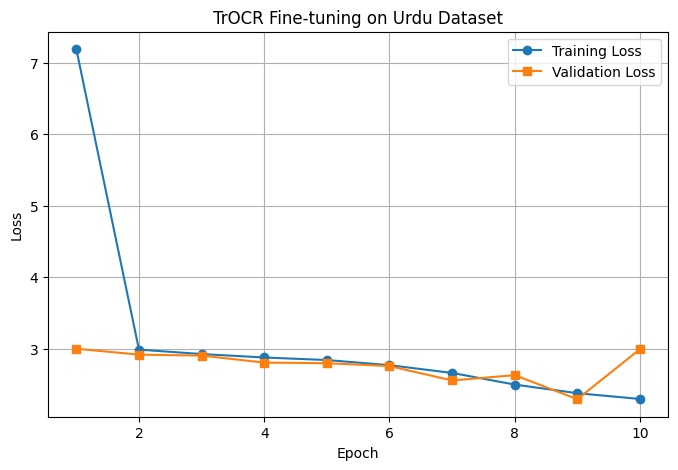

Saved chart as training_loss.png


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', label='Training Loss')
plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('TrOCR Fine-tuning on Urdu Dataset')
plt.legend()
plt.grid(True)
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved chart as training_loss.png')

---
## 9 - Evaluate the Model

Tests performance on images the model has never seen (the test set). `model.eval()` mode ensures weights are not updated during this step.

Two metrics are reported:
- **Exact-match accuracy** - the percentage of predictions that match the true text perfectly, character for character. Very strict.
- **Character Error Rate (CER)** - the percentage of characters that would need to be added, removed, or changed to turn the prediction into the correct answer. Much more informative for OCR, since it gives partial credit for close-but-not-perfect predictions instead of an all-or-nothing score.

Note: because the tokenizer now treats each Urdu character as its own token, the raw decoded text may have extra spaces inserted between letters (a known side effect of `add_tokens`, not an error). A cleanup step below removes these before comparing and printing.

In [ ]:
import re


def clean_spacing(text):
    """Removes artificial single-space gaps inserted between individual
    characters by the tokenizer's added-token decoding, while preserving
    real word-boundary spaces (which show up as 2+ consecutive spaces)."""
    text = re.sub(r' {2,}', '<SPACE>', text)
    text = text.replace(' ', '')
    text = text.replace('<SPACE>', ' ')
    return text.strip()


def char_error_rate(reference, hypothesis):
    """Computes Character Error Rate via edit distance (Levenshtein), with
    no external dependencies. Returns a value between 0 (perfect) and 1+ (very wrong)."""
    ref, hyp = list(reference), list(hypothesis)
    if len(ref) == 0:
        return 0.0 if len(hyp) == 0 else 1.0

    prev_row = list(range(len(hyp) + 1))
    for i, r_char in enumerate(ref, start=1):
        curr_row = [i] + [0] * len(hyp)
        for j, h_char in enumerate(hyp, start=1):
            cost = 0 if r_char == h_char else 1
            curr_row[j] = min(
                prev_row[j] + 1,        # deletion
                curr_row[j - 1] + 1,    # insertion
                prev_row[j - 1] + cost  # substitution
            )
        prev_row = curr_row

    return prev_row[-1] / len(ref)


model.eval()
print('=== Model Evaluation on Test Images ===\n')

correct = 0
total = 0
total_cer = 0.0

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].clone()
        # Labels contain -100 for padding (needed for loss masking during training),
        # but -100 is not a valid token id for decoding - swap it back to pad_token_id first
        labels[labels == -100] = processor.tokenizer.pad_token_id

        # Plain greedy decoding can get stuck in a repetition loop (e.g. repeating
        # the same character forever) when the model isn't fully confident. Beam
        # search plus a no-repeat-ngram constraint and a repetition penalty stop that:
        generated_ids = model.generate(
            pixel_values,
            max_new_tokens=64,
            num_beams=4,
            no_repeat_ngram_size=3,
            repetition_penalty=1.3,
            early_stopping=True,
        )
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
        actual_text = processor.batch_decode(labels, skip_special_tokens=True)

        for pred, actual in zip(generated_text, actual_text):
            pred_clean = clean_spacing(pred)
            actual_clean = clean_spacing(actual)

            total += 1
            if pred_clean == actual_clean:
                correct += 1

            total_cer += char_error_rate(actual_clean, pred_clean)

            print(f'Predicted: {pred_clean}')
            print(f'Actual:    {actual_clean}')
            print()

accuracy = (correct / total) * 100 if total > 0 else 0
avg_cer = (total_cer / total) * 100 if total > 0 else 0
char_accuracy = 100 - avg_cer

print(f'Exact-match accuracy: {accuracy:.1f}% ({correct}/{total} correct)')
print(f'Character Error Rate: {avg_cer:.1f}%')
print(f'Character-level accuracy: {char_accuracy:.1f}%')

=== Model Evaluation on Test Images ===

Predicted: حححتتت ت ی ییی ااا اناایا یاییںییہیہہیی
Actual:    محنت کبھی رائیگاں نہیں جاتی

Predicted: پاوواارار
Actual:    بجلیاور

Predicted: دداااناا ااییی ی یا ل ت ے ےےےہےے
Actual:    قناعت ایک بڑی دولت ہے

Predicted: اواااداییی یید ددتددد ا رضف ض ہ ے ہہ ہےہہےےے
Actual:    والدین کی خدمت اولاد پر فرض ہے

Predicted: وددد ن ے س تت ا اااکاا ہا ح ص ہ ےے ےہےےےہ
Actual:    وطن سے محبت ایمان کا حصہ ہے

Predicted: کککاتتبییی ییھ ڑ ےس سسس س ل م ا ہ ت
Actual:    کتابیں پڑھنے سے علم بڑھتا ہے

Predicted: جججاتتتااا ت ی ے ک ن ننن ا ہےے ےےے
Actual:    جہالت اندھیرے کی مانند ہے

Predicted: نننممما ممسمملمم پ ر ہ ے ہہ ہےہہےےےہے
Actual:    نماز مسلمانوں پر فرض ہے

Predicted: ککتتتا ااسااننن ی ں ب ت ق ے ہ وےےے ےےہےے
Actual:    کتاب انسان کی بہترین دوست ہے

Predicted: ججہاتتتااات د ے ی ک ن نن ا ہ ےہ ہہے
Actual:    جہالت اندھیرے کی مانند ہے

Predicted: وووقتتت ھ ی ا اا ںاااتات تتہتتںتت
Actual:    وقت کبھی واپس نہیں آتا

Predicted: نمننانننمممسممل پ ر ہ ے ض ہہہےے

For your submission, record:
- `My model accuracy is X%` - report both the exact-match accuracy and the character-level accuracy from above (character-level accuracy is generally the more meaningful number for OCR)
- `Training loss went from X to X` - first vs. last value in `loss_history` from Section 8, and mention the validation loss trend too
- The loss curve chart from Section 8.5 (training_loss.png) as your submission screenshot
- 3-5 examples above where predicted does not equal actual (for Week 5 discussion)

---
## 10 - Save Model to Google Drive

Colab sessions reset on close. Saving to Drive means the fine-tuned model can be reloaded next week without retraining.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/SI26-urdu-ocr-model'
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

print(f'Model saved to Google Drive: {save_path}')
print('This can be reloaded next week without retraining.')

After running this cell, open https://drive.google.com and confirm the folder `SI26-urdu-ocr-model` exists before closing Colab.

---
## 11 - Export Updated Dataset for GitHub

If you generated extra synthetic data in Section 4.5, your local `data/` folder now has more images and labels than your original GitHub upload. This section packages everything - original images, new synthetic images, and the updated `labels.csv` - into one zip you can download and push to your repo.

In [ ]:
import shutil

zip_base_name = 'data_updated'
shutil.make_archive(zip_base_name, 'zip', '.', 'data')

zip_size_mb = os.path.getsize(f'{zip_base_name}.zip') / (1024 * 1024)
print(f'Created {zip_base_name}.zip ({zip_size_mb:.1f} MB)')
print('Starting download...')

from google.colab import files
files.download(f'{zip_base_name}.zip')

Once downloaded:
1. Unzip `data_updated.zip` on your computer
2. Go to your GitHub repo, then Add file, then Upload files
3. Drag in the updated `data/` folder (this replaces `labels.csv` with the version containing all your original + new rows, and adds the new `synthetic_gen/` image folder)
4. Commit directly to `main`

---
## Summary

- Uploaded and extracted dataset directly in this notebook
- Generated additional synthetic training data on demand
- Filtered to labeled rows only for clean training
- Loaded pretrained `microsoft/trocr-base-printed` model onto GPU
- Extended the tokenizer/model vocabulary so Urdu characters can actually be represented and learned
- Fine-tuned for a configurable number of epochs (see `num_epochs` in Section 8), with loss logged per batch and per epoch
- Evaluated on a held-out test set with exact-match accuracy
- Saved the fine-tuned model and processor to Google Drive
- Exported the updated dataset for GitHub

Next step: label more of the remaining rows in `data/labels.csv`, generate more synthetic data, or both - then re-run Sections 5-11 to keep improving accuracy.

---
### Sources & Links
- Google Colab: https://colab.research.google.com
- Google Drive: https://drive.google.com
- Hugging Face Transformers: https://huggingface.co/docs/transformers
- TrOCR model (Microsoft): https://huggingface.co/microsoft/trocr-base-printed
- TrOCR paper: https://arxiv.org/abs/2109.10282